# Capítulo 3 - Exercício 1: Testando um novo Classficador

O objetivo deste notebook é testar o um classificardor no MNIST que consiga uma acuracia de 97%. Nos iremos usar o KneigborsClassifier como nosso primeiro teste.

## Plano do exercício

1. Carregar os dados brutos.

## Configuração

Importamos as bibliotecas usadas no exercício e verificamos versões mínimas. Mantemos uma semente fixa para tornar os resultados mais reprodutíveis.

In [24]:
import sys
from pathlib import Path
import tarfile
import urllib.request

import numpy as np
import pandas as pd

from packaging import version
import sklearn

assert sys.version_info >= (3, 7)
assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

np.random.seed(42)

# MNIST

In [25]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False)
print(mnist.DESCR)


**Author**: Yann LeCun, Corinna Cortes, Christopher J.C. Burges  
**Source**: [MNIST Website](http://yann.lecun.com/exdb/mnist/) - Date unknown  
**Please cite**:  

The MNIST database of handwritten digits with 784 features, raw data available at: http://yann.lecun.com/exdb/mnist/. It can be split in a training set of the first 60,000 examples, and a test set of 10,000 examples  

It is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-size image. It is a good database for people who want to try learning techniques and pattern recognition methods on real-world data while spending minimal efforts on preprocessing and formatting. The original black and white (bilevel) images from NIST were size normalized to fit in a 20x20 pixel box while preserving their aspect ratio. The resulting images contain grey levels as a result of the anti-aliasing technique used by the normalization algorithm. the images were centered in a 28x28 image b

### Testando os dados

In [26]:
X, y = mnist.data, mnist.target
X
y

array(['5', '0', '4', ..., '4', '5', '6'], shape=(70000,), dtype=object)

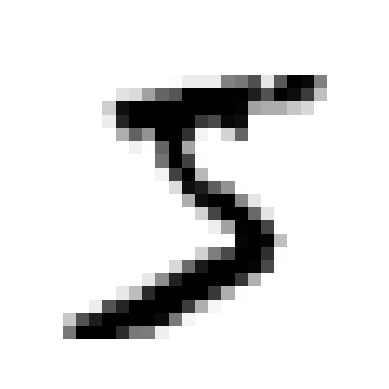

'0'

In [27]:
import matplotlib.pyplot as plt

def plot_digit(image_data):
    image = image_data.reshape(28,28)
    plt.imshow(image, cmap='binary')
    plt.axis("off")

some_digit = X[0]
plot_digit(some_digit)
plt.show()
y[1]


### Dividindo entre dados de treino e dados de teste

In [28]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

# Treinando o classficador binario

In [29]:
y_train_5 = (y_train == '5') 
y_test_5 = (y_test == '5')

In [30]:
from sklearn.neighbors import KNeighborsClassifier

knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_train_5)

KNeighborsClassifier()

In [31]:
knn_clf.predict([some_digit])  # True

array([ True])

## Calculando a Acurácia com a Validação Cruzada
### Nos dados de treino*

In [32]:
from sklearn.model_selection import cross_val_score

cross_val_score(knn_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.9941, 0.993 , 0.9931])

## Grid Search

In [33]:
from sklearn.model_selection import GridSearchCV

param_grid = [
{"n_neighbors": [2,3,5],
 "weights": ["uniform", "distance"]
}
]

grid_search = GridSearchCV(knn_clf, param_grid, cv=3, scoring="accuracy")
grid_search.fit(X_train, y_train_5)

GridSearchCV(cv=3, estimator=KNeighborsClassifier(),
             param_grid=[{'n_neighbors': [2, 3, 5],
                          'weights': ['uniform', 'distance']}],
             scoring='accuracy')

In [34]:
print("Parametros da melhor busca do grid_search: " + str(grid_search.best_params_))
print("Score da melhor busca do grid_search: "+ str(grid_search.best_score_))

Parametros da melhor busca do grid_search: {'n_neighbors': 5, 'weights': 'uniform'}
Score da melhor busca do grid_search: 0.9934


## Modelo otimizado

In [36]:
best_knn_clf = grid_search.best_estimator_
y_test_pred = best_knn_clf.predict(X_test)


In [37]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test_5, y_test_pred) 

0.9939

# Treinando o classficador completo

In [39]:
from sklearn.neighbors import KNeighborsClassifier

knn_clf_completo = KNeighborsClassifier()
knn_clf_completo.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
knn_clf_completo.predict([some_digit])  # 5

array(['5'], dtype=object)

## Calculando a Acurácia com a Validação Cruzada
### Nos dados de treino*

In [42]:
from sklearn.model_selection import cross_val_score

cross_val_score(knn_clf_completo, X_train, y_train, cv=3, scoring="accuracy")

array([0.9676 , 0.9671 , 0.96755])

## Grid Search

In [46]:
from sklearn.model_selection import GridSearchCV

param_grid = [
    { "n_neighbors": [2,3,5],
        "weights": ["uniform","distance"]
    }
]

grid_search_cmplt = GridSearchCV(knn_clf_completo, param_grid, cv=3, scoring="accuracy")
grid_search_cmplt.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=KNeighborsClassifier(),
             param_grid=[{'n_neighbors': [2, 3, 5],
                          'weights': ['uniform', 'distance']}],
             scoring='accuracy')

In [50]:
print("Parametros da melhor busca do grid_search: " + str(grid_search_cmplt.best_params_))
print("Score da melhor busca do grid_search: "+ str(grid_search_cmplt.best_score_))

Parametros da melhor busca do grid_search: {'n_neighbors': 3, 'weights': 'distance'}
Score da melhor busca do grid_search: 0.9693333333333333


# Definindo o Modelo Otimizado

In [52]:
best_knn_clf_cmplt = grid_search_cmplt.best_estimator_
y_test_pred_complet = best_knn_clf_cmplt.predict(X_test)

In [53]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_test_pred_complet)

0.9717